<a href="https://colab.research.google.com/github/dhunsyam/Advance-Databases/blob/gh-pages/Data_Split.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Rows: 25535
Unique substations: 52
X shape (rows, one-hot columns): (25535, 52)
Train: (17874, 52) (17874,)
Val:  (3830, 52) (3830,)
Test:  (3831, 52) (3831,)
Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - loss: 7.2757 - mae: 2.3023 - val_loss: 5.5431 - val_mae: 1.9481
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.9337 - mae: 1.8260 - val_loss: 3.1417 - val_mae: 1.4571
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.7789 - mae: 1.3848 - val_loss: 2.0935 - val_mae: 1.2457
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.2108 - mae: 1.2708 - val_loss: 2.0559 - val_mae: 1.2369
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.1576 - mae: 1.2588 - val_loss: 2.0294 - val_mae: 1.2335
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.1266 - mae: 1.2518 - val_loss: 2.0162 - val_mae: 1.2303
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.1163 - mae: 1.2483 - val_loss: 2.0135 - val_mae: 1.2297
Epoch 8/50
18/18 ━━━━━━━━━━

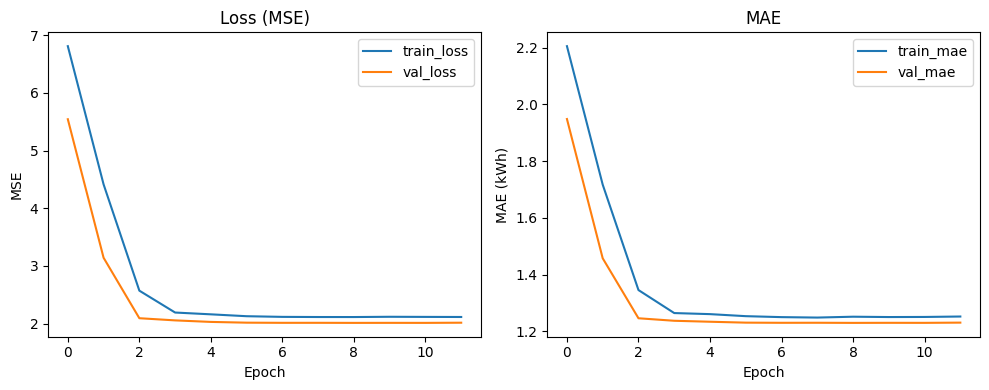

Saved model: ffnn_substation_usagekwh.keras


In [2]:
#Google Colab Code: SubstationName -> UsageKWH (Feedforward NN)
#Copy/paste the code blocks into Colab cells. Update CSV_PATH to your uploaded file name.
# =========================
# Google Colab: Tabular Regression (FFNN)
# Predict UsageKWH from SubstationName (one-hot encoded)
# Steps followed:
# 1) Keep only SubstationName and UsageKWH
# 2) One-hot encode SubstationName -> X
# 3) Assign UsageKWH -> y
# 4) Split into train/val/test
# 5) Train a feedforward neural network
# =========================
# (A) Upload your CSV in Colab:
# from google.colab import files
# uploaded = files.upload()
# Then set CSV_PATH = "<your_file_name>.csv"
# (B) Or mount Google Drive:
# from google.colab import drive
# drive.mount('/content/drive')
# CSV_PATH = "/content/drive/MyDrive/<path>/<file>.csv"
!pip -q install pandas scikit-learn tensorflow matplotlib
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
# -----------------------------
# 1) Load data and keep only required variables
# -----------------------------
CSV_PATH = "Sample Test Data Consumption_Active_Import.csv" # <-- change if needed
df = pd.read_csv(CSV_PATH)
df = df[["SubstationName", "UsageKWH"]].dropna()
# Optional but recommended: remove exact duplicates
# (If your dataset has many duplicates, this avoids biasing training.)
df = df.drop_duplicates()
print("Rows:", len(df))
print("Unique substations:", df["SubstationName"].nunique())
# -----------------------------
# 2) One-hot encode SubstationName -> X
# -----------------------------
X = pd.get_dummies(df["SubstationName"], prefix="Substation", dtype="int8")
print("X shape (rows, one-hot columns):", X.shape)
# -----------------------------
# 3) Assign UsageKWH -> y
# -----------------------------
y = df["UsageKWH"].astype("float32")
# -----------------------------
# 4) Split into train/val/test (70/15/15)
# -----------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
X, y,
test_size=0.30,
random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
X_temp, y_temp,
test_size=0.50,
random_state=42
)
print("Train:", X_train.shape, y_train.shape)
print("Val: ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)
# Convert to NumPy arrays for TensorFlow
X_train = X_train.values
X_val = X_val.values
X_test = X_test.values
# -----------------------------
# 5) Train a feedforward neural network (regression)
# -----------------------------
model = tf.keras.Sequential([
layers.Input(shape=(X_train.shape[1],)),
layers.Dense(64, activation="relu"),
layers.Dropout(0.2),
layers.Dense(32, activation="relu"),
layers.Dropout(0.1),
layers.Dense(1) # linear output for regression
])
model.compile(
optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
loss="mse",
metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]
)
callbacks = [
tf.keras.callbacks.EarlyStopping(
monitor="val_loss",
patience=3,
restore_best_weights=True
)
]
history = model.fit(
X_train, y_train,
validation_data=(X_val, y_val),
epochs=50,
batch_size=1024,
callbacks=callbacks,
verbose=1
)
# Evaluate on the TEST set
test_mse, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"TEST MSE: {test_mse:.4f}")
print(f"TEST MAE: {test_mae:.4f} kWh")
# -----------------------------
# Plot training curves (useful for assignment evidence)
# -----------------------------
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history["mae"], label="train_mae")
plt.plot(history.history["val_mae"], label="val_mae")
plt.title("MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE (kWh)")
plt.legend()
plt.tight_layout()
plt.show()
# -----------------------------
# Save model artefact (download from Colab if needed)
# -----------------------------
MODEL_PATH = "ffnn_substation_usagekwh.keras"
model.save(MODEL_PATH)
print("Saved model:", MODEL_PATH)
# Optional download from Colab:
# from google.colab import files
# files.download(MODEL_PATH)